# Aberrations

Acquire corrector tableau data and explore aberration parameters with the existing GUI workflow.


### Run the servers

Make sure you are on the VPN and the AutoScript server is running. Then start the asyncroscopy Tango servers from the repository root:

```bash
uv run startup_scripts/run_servers.py
```


### Imports


In [8]:
%matplotlib inline
import os
import json
import time

import matplotlib.pylab as plt
import numpy  as np
import ipywidgets as widgets

import tango
import tiled
import tiled.client

%load_ext autoreload
%autoreload 2

import correction
import pyTEMlib

print(f"pyTEMlib version: {pyTEMlib.__version__}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
pyTEMlib version: 0.2026.3.0


### Ping servers


In [9]:
DB_HOST = "10.46.217.241"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'eds', 'camera', 'data', 'instrument', 'corrector']

for name in server_names:
    device_name = f"asyncroscopy/{name}/default"
    proxy = tango.DeviceProxy(device_name)
    proxy.ping()
    print(device_name, proxy.state())



asyncroscopy/stage/default ON
asyncroscopy/scan/default ON
asyncroscopy/eds/default ON
asyncroscopy/camera/default ON
asyncroscopy/data/default ON
asyncroscopy/instrument/default ON
asyncroscopy/corrector/default ON


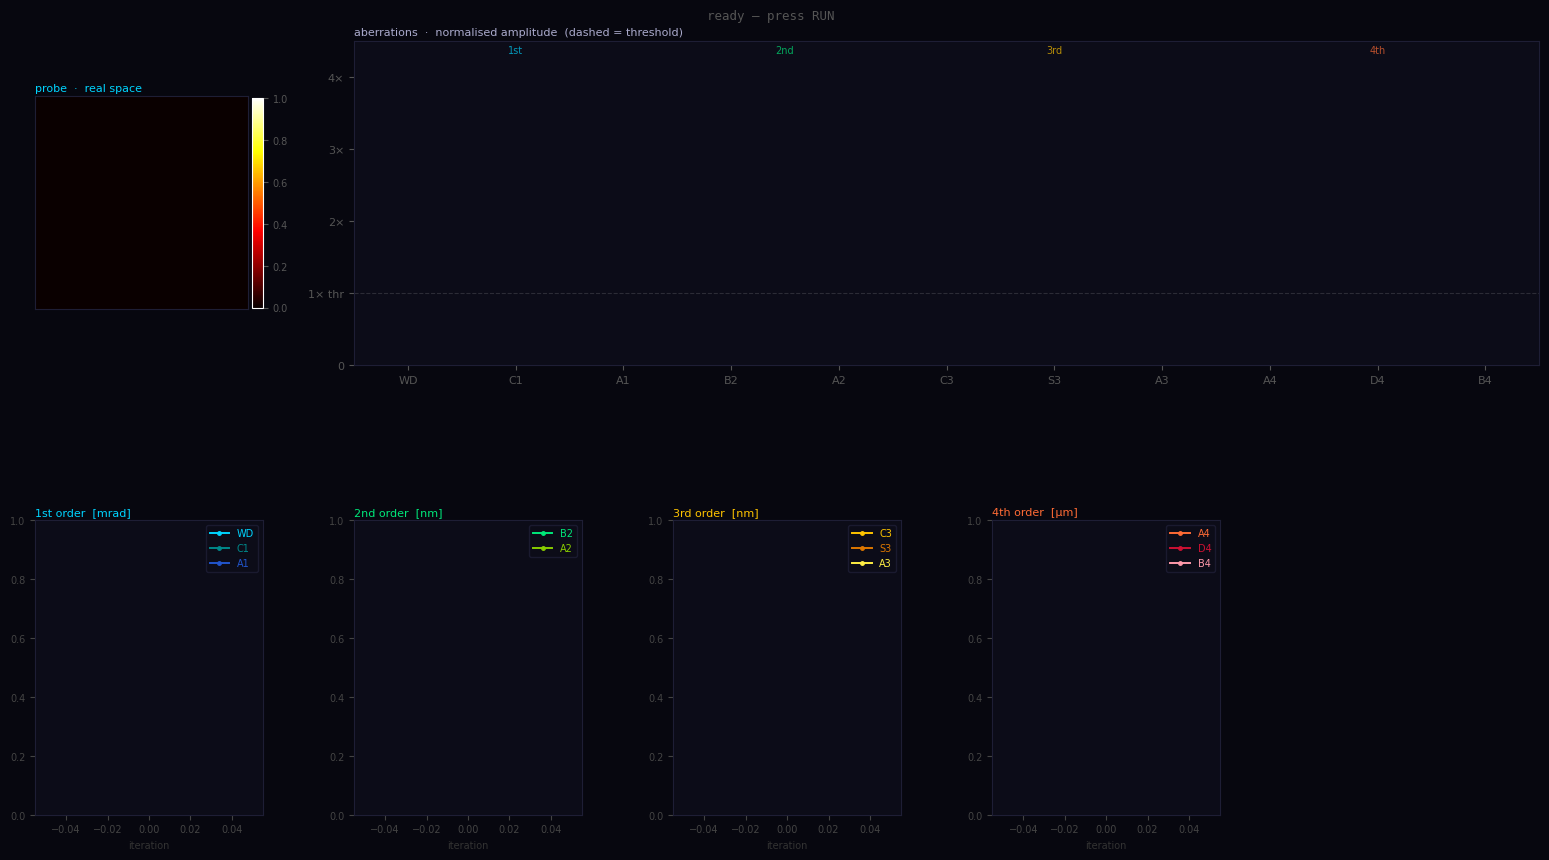

In [12]:


class AberrationCorrectionGUI:
    """Interactive aberration correction GUI wrapped in a class."""

    first_order = ["WD", "C1", "A1"]
    second_order = ["B2", "A2"]
    third_order = ["C3", "S3", "A3"]
    fourth_order = ["A4", "D4", "B4"]
    all_keys = first_order + second_order + third_order + fourth_order

    # C1, C3 are scalar — Tango server expects "KEY x" (one float).
    # All others are 2-component — expects "KEY x y".
    SCALAR_KEYS = {"C1", "C3"}

    fourth_order_factor = 0.50

    thresholds = {
        "WD": 1e-3,
        "C1": 5e-9,
        "A1": 5e-9,
        "B2": 50e-9,
        "A2": 100e-9,
        "C3": 0.7e-6,
        "S3": 0.5e-6,
        "A3": 0.5e-6,
        "A4": 5e-6,
        "D4": 4e-6,
        "B4": 5e-6,
    }

    factors = {
        "WD": 0.5,
        "C1": 1.0,
        "A1": 1.0,
        "B2": 0.75,
        "A2": 0.75,
        "C3": 0.5,
        "S3": 0.75,
        "A3": 0.75,
        "A4": 0.5,
        "D4": 0.5,
        "B4": 0.3,
    }

    display_scale = {
        "WD": 1e3,
        "C1": 1e9,
        "A1": 1e9,
        "B2": 1e9,
        "A2": 1e9,
        "C3": 1e9,
        "S3": 1e9,
        "A3": 1e9,
        "A4": 1e6,
        "D4": 1e6,
        "B4": 1e6,
    }

    display_units = {
        "WD": "mrad",
        "C1": "nm",
        "A1": "nm",
        "B2": "nm",
        "A2": "nm",
        "C3": "nm",
        "S3": "nm",
        "A3": "nm",
        "A4": "µm",
        "D4": "µm",
        "B4": "µm",
    }

    order_groups = {
        "1st": {"keys": first_order, "color": "#00d4ff"},
        "2nd": {"keys": second_order, "color": "#00e87a"},
        "3rd": {"keys": third_order, "color": "#ffc400"},
        "4th": {"keys": fourth_order, "color": "#ff6b35"},
    }

    key_colors = {
        "WD": "#00d4ff",
        "C1": "#00888a",
        "A1": "#2255cc",
        "B2": "#00e87a",
        "A2": "#88cc00",
        "C3": "#ffc400",
        "S3": "#dd7700",
        "A3": "#ffee44",
        "A4": "#ff6b35",
        "D4": "#cc1133",
        "B4": "#ff99aa",
    }

    def __init__(self, corrector_proxy):
        self.corrector = corrector_proxy
        self._thread = None
        self._stop_flag = threading.Event()
        self.history = {k: [] for k in self.all_keys}

        plt.style.use("dark_background")
        self.fig = plt.figure(figsize=(16, 9), facecolor="#07070f")
        try:
            self.fig.canvas.header_visible = False
        except AttributeError:
            pass

        self.gs = gridspec.GridSpec(
            2,
            5,
            figure=self.fig,
            left=0.04,
            right=0.98,
            top=0.93,
            bottom=0.07,
            wspace=0.40,
            hspace=0.50,
            width_ratios=[1, 1, 1, 1, 1],
            height_ratios=[1.1, 1],
        )

        self.ax_probe = self.fig.add_subplot(self.gs[0, 0])
        self.ax_bars = self.fig.add_subplot(self.gs[0, 1:])
        self.ax_hist = {
            "1st": self.fig.add_subplot(self.gs[1, 0]),
            "2nd": self.fig.add_subplot(self.gs[1, 1]),
            "3rd": self.fig.add_subplot(self.gs[1, 2]),
            "4th": self.fig.add_subplot(self.gs[1, 3]),
        }

        for ax in [self.ax_probe, self.ax_bars] + list(self.ax_hist.values()):
            ax.set_facecolor("#0c0c18")
            for sp in ax.spines.values():
                sp.set_color("#1e1e35")

        self._build_widgets()
        self.probe_panel()
        self.bar_panel()
        self.history_panel()
        self.status_line()

        self.display()

    def _build_widgets(self):
        self.w_max_iter = widgets.BoundedIntText(
            value=5,
            min=1,
            max=20,
            step=1,
            description="Max outer:",
            style={"description_width": "70px"},
            layout=widgets.Layout(width="160px"),
        )
        self.w_fourth_factor = widgets.BoundedFloatText(
            value=0.5,
            min=0.05,
            max=1.0,
            step=0.05,
            description="4th ×:",
            style={"description_width": "60px"},
            layout=widgets.Layout(width="150px"),
        )
        self.w_run = widgets.Button(
            description="▶  RUN",
            style={"button_color": "#05B554", "font_weight": "bold"},
            layout=widgets.Layout(width="100px", height="32px"),
        )
        self.w_stop = widgets.Button(
            description="■  STOP",
            button_style="danger",
            layout=widgets.Layout(width="100px", height="32px"),
        )
        self.log_out = widgets.Output(
            layout=widgets.Layout(
                width="100%",
                height="220px",
                overflow_y="auto",
                padding="8px 12px",
            )
        )

        self.log_panel = widgets.VBox(
            [
                widgets.HTML(
                    value=(
                        '<div style="'
                        "font-family:monospace;"
                        "font-size:10px;"
                        "letter-spacing:4px;"
                        "color:#334;"
                        "background:#0a0a14;"
                        "padding:5px 12px 4px 12px;"
                        "border-bottom:1px solid #1a1a30;"
                        '">OUTPUT LOG</div>'
                    )
                ),
                self.log_out,
            ],
            layout=widgets.Layout(border="1px solid #1a1a30", width="100%"),
        )

    def probe_panel(self):
        ax_probe = self.ax_probe
        ax_probe.set_title("probe  ·  real space", fontsize=8, color="#00d4ff", pad=4, loc="left")
        ax_probe.set_xticks([])
        ax_probe.set_yticks([])
        self.probe_im = ax_probe.imshow(
            np.zeros((64, 64)),
            cmap="hot",
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        cb = self.fig.colorbar(self.probe_im, ax=ax_probe, fraction=0.046, pad=0.02)
        cb.ax.tick_params(labelsize=7, colors="#555")

    def bar_panel(self):
        ax_bars = self.ax_bars
        ax_bars.set_title(
            "aberrations  ·  normalised amplitude  (dashed = threshold)",
            fontsize=8,
            color="#aaaacc",
            pad=4,
            loc="left",
        )
        ax_bars.set_xlim(-0.5, len(self.all_keys) - 0.5)
        ax_bars.set_xticks(range(len(self.all_keys)))
        ax_bars.set_xticklabels(self.all_keys, fontsize=8)
        ax_bars.set_ylim(0, 4.5)
        ax_bars.set_yticks([0, 1, 2, 3, 4])
        ax_bars.set_yticklabels(["0", "1× thr", "2×", "3×", "4×"], fontsize=7, color="#555")
        ax_bars.tick_params(colors="#555", labelsize=8)
        ax_bars.axhline(1.0, color="#ffffff22", linewidth=0.8, linestyle="--")

        self.bar_rects = ax_bars.bar(
            range(len(self.all_keys)),
            [0] * len(self.all_keys),
            color=[self.key_colors[k] for k in self.all_keys],
            alpha=0.75,
            edgecolor="none",
            width=0.6,
        )

        for ord_name, grp in self.order_groups.items():
            idx = [self.all_keys.index(k) for k in grp["keys"]]
            ax_bars.text(
                np.mean(idx),
                4.3,
                ord_name,
                ha="center",
                va="bottom",
                fontsize=7,
                color=grp["color"],
                alpha=0.7,
            )

    def history_panel(self):
        self.history_lines = {}
        for ord_name, grp in self.order_groups.items():
            ax = self.ax_hist[ord_name]
            key0 = grp["keys"][0]
            ax.set_title(
                f"{ord_name} order  [{self.display_units[key0]}]",
                fontsize=8,
                color=grp["color"],
                pad=3,
                loc="left",
            )
            ax.tick_params(colors="#444", labelsize=7)
            ax.set_xlabel("iteration", fontsize=7, color="#333")
            ax.set_ylim(0, 1)

            self.history_lines[ord_name] = {}
            for k in grp["keys"]:
                ax.axhline(
                    self.thresholds[k] * self.display_scale[k],
                    color=self.key_colors[k],
                    linewidth=0.6,
                    linestyle=":",
                    alpha=0.4,
                )
                line, = ax.plot(
                    [],
                    [],
                    color=self.key_colors[k],
                    linewidth=1.4,
                    label=k,
                    marker="o",
                    markersize=2.5,
                )
                self.history_lines[ord_name][k] = line

            leg = ax.legend(
                fontsize=7,
                loc="upper right",
                facecolor="#0c0c18",
                edgecolor="#1e1e35",
            )
            for text, k in zip(leg.get_texts(), grp["keys"]):
                text.set_color(self.key_colors[k])

    def status_line(self):
        self.status_text = self.fig.text(
            0.5,
            0.965,
            "ready — press RUN",
            ha="center",
            va="top",
            fontsize=9,
            color="#555",
            fontfamily="monospace",
        )

    def norm(self, v):
        return float(np.linalg.norm(v))

    def acquire(self, tableau_type):
        raw = self.corrector.acquire_tableau(tableau_type)
        return json.loads(raw)["result"]["aberrations"]

    def correct(self, key, v):
        v = list(v)
        if key in self.SCALAR_KEYS:
            self.corrector.correct_aberration(f"{key} {v[0]}")
        else:
            self.corrector.correct_aberration(f"{key} {v[0]} {v[1]}")

    def correct_12(self, ab):
        thresholds = {
            "WD": 0.2e-3,
            "C1": 3e-9,
            "A1": 3e-9,
            "B2": 50e-9,
            "A2": 50e-9,
        }
        factors = {"WD": 0.5, "C1": 1.0, "A1": 1.0, "B2": 0.75, "A2": 0.5}

        corrected = []
        for key in thresholds:
            if self.norm(ab.get(key, [0, 0])) > thresholds[key]:
                self.correct(key, np.array(ab[key]) * factors[key])
                corrected.append(key)
        return corrected

    def correct_3rd(self, ab):
        corrected = []
        for key in ["C3", "S3", "A3"]:
            if self.norm(ab.get(key, [0, 0])) > self.thresholds[key]:
                self.correct(key, [v * self.factors[key] for v in ab[key]])
                corrected.append(key)
        return corrected

    def correct_4th(self, ab, factor=1):
        corrected = []
        for key in self.fourth_order:
            if self.norm(ab.get(key, [0, 0])) > self.thresholds[key]:
                self.correct(key, [v * self.factors[key] * factor for v in ab[key]])
                corrected.append(key)
        return corrected

    def update_probe(self, ab):
        N = 64
        C1_nm = self.norm(ab.get("C1", [0, 0])) * 1e9
        A1_v = ab.get("A1", [0, 0])
        A1_nm = self.norm(A1_v) * 1e9
        A1_ang = np.arctan2(A1_v[1], A1_v[0])
        C3_nm = self.norm(ab.get("C3", [0, 0])) * 1e9
        sigma = 3.5 * (1 + C1_nm / 5 * 0.5 + C3_nm / 350 * 0.3)
        astig = min(A1_nm / 5 * 0.6, 2.0)
        y, x = np.ogrid[:N, :N]
        dx, dy = x - N / 2, y - N / 2
        phi = np.arctan2(dy, dx)
        r = np.hypot(dx, dy)
        sig_eff = sigma * (1 + astig * np.cos(2 * (phi - A1_ang)) * 0.25)
        probe = np.exp(-(r**2) / (2 * sig_eff**2))
        probe /= probe.max()
        self.probe_im.set_data(probe)
        self.probe_im.set_clim(0, 1)

    def record_and_redraw(self, ab, measured_keys=None):
        if measured_keys is None:
            measured_keys = self.all_keys
        for k in self.all_keys:
            if k in measured_keys:
                self.history[k].append(self.norm(ab.get(k, [0, 0])))
            else:
                last = self.history[k][-1] if self.history[k] else 0.0
                self.history[k].append(last)

        self.update_bars(ab)
        self.update_probe(ab)
        self.update_history()
        self.redraw()

    def update_bars(self, ab):
        for i, k in enumerate(self.all_keys):
            amp = self.norm(ab.get(k, [0, 0]))
            normalised = amp / self.thresholds[k]
            self.bar_rects[i].set_height(min(normalised, 4.5))
            self.bar_rects[i].set_alpha(0.9 if amp > self.thresholds[k] else 0.30)

    def update_history(self):
        n = len(self.history[self.all_keys[0]])
        if n == 0:
            return
        iters = list(range(1, n + 1))
        for ord_name, grp in self.order_groups.items():
            all_vals = []
            for k in grp["keys"]:
                y = [v * self.display_scale[k] for v in self.history[k]]
                self.history_lines[ord_name][k].set_data(iters, y)
                all_vals.extend(y)

            ax = self.ax_hist[ord_name]
            ax.set_xlim(1, max(n, 2))
            if all_vals:
                ymax = max(all_vals) * 1.25
                yfloor = self.thresholds[grp["keys"][0]] * self.display_scale[grp["keys"][0]] * 1.5
                ax.set_ylim(0, max(ymax, yfloor))

    def redraw(self):
        self.fig.canvas.draw_idle()

    def run_correction(self, max_outer, fourth_factor, log_out):
        self._stop_flag.clear()

        with log_out:
            log_out.clear_output(wait=True)
            print("─" * 52)
            print(f"  Aberration correction  —  max {max_outer} outer iterations")
            print("─" * 52)

        def stopped():
            if self._stop_flag.is_set():
                with log_out:
                    print("\n  ⚠  Stopped by user.")
                self.status_text.set_text("stopped")
                self.status_text.set_color("#ff4444")
                self.redraw()
                return True
            return False

        def safe_acquire(tableau_type, label):
            try:
                return self.acquire(tableau_type)
            except Exception as exc:
                with log_out:
                    print(f"  ERROR acquiring {label}: {exc}")
                self.status_text.set_text("error")
                self.status_text.set_color("#ff4444")
                self.redraw()
                return None

        for outer in range(max_outer):
            if stopped():
                return

            with log_out:
                print(f"\n━━  Outer iteration {outer + 1}/{max_outer}  ━━")

            inner = 0
            while True:
                if stopped():
                    return
                inner += 1
                with log_out:
                    print(f"  [Fast]  inner iter {inner}")
                self.status_text.set_text(f"outer {outer + 1}  ·  Fast iter {inner}")
                self.status_text.set_color("#00d4ff")
                self.redraw()

                ab = safe_acquire("Fast 1", "Fast 1")
                if ab is None:
                    return

                self.record_and_redraw(ab, measured_keys=self.first_order + self.second_order)

                corrected_12 = self.correct_12(ab)
                with log_out:
                    tag = ", ".join(corrected_12) if corrected_12 else "(none — 1st/2nd clean)"
                    print(f"    corrected: {tag}")

                break

            if stopped():
                return

            with log_out:
                print("  [Enhanced]")
            self.status_text.set_text(f"outer {outer + 1}  ·  Enhanced 40")
            self.status_text.set_color("#ffc400")
            self.redraw()

            ab_enh = safe_acquire("Enhanced 40", "Enhanced 40")
            if ab_enh is None:
                return

            self.record_and_redraw(ab_enh, measured_keys=self.all_keys)

            corrected_3 = self.correct_3rd(ab_enh)
            if corrected_3:
                with log_out:
                    print(f"    3rd order corrected: {corrected_3}")
                continue

            corrected_4 = self.correct_4th(ab_enh, fourth_factor)
            if corrected_4:
                with log_out:
                    print(f"    4th order corrected: {corrected_4}")
                continue

            with log_out:
                print(f"\n  ✦  Converged after outer iteration {outer + 1}.")
            self.status_text.set_text(f"converged — outer iter {outer + 1}")
            self.status_text.set_color("#00e87a")
            self.redraw()
            return

        with log_out:
            print(f"\n  Done — {max_outer} outer iterations complete.")
        self.status_text.set_text("done")
        self.status_text.set_color("#00e87a")
        self.redraw()

    def on_run(self, _=None):
        self.history = {k: [] for k in self.all_keys}
        for ord_name, grp in self.order_groups.items():
            for k in grp["keys"]:
                self.history_lines[ord_name][k].set_data([], [])
        self._stop_flag = threading.Event()
        self._thread = threading.Thread(
            target=self.run_correction,
            args=(self.w_max_iter.value, self.w_fourth_factor.value, self.log_out),
            daemon=True,
        )
        self._thread.start()

    def on_stop(self, _=None):
        self._stop_flag.set()

    def display(self):
        self.w_run.on_click(self.on_run)
        self.w_stop.on_click(self.on_stop)

        controls = widgets.HBox(
            [self.w_max_iter, self.w_fourth_factor, self.w_run, self.w_stop],
            layout=widgets.Layout(gap="12px", align_items="center", padding="6px 0"),
        )

        display(widgets.VBox([controls, self.log_panel], layout=widgets.Layout(gap="6px")))
        plt.show()


gui = AberrationCorrectionGUI(corrector_proxy)


### Connect to devices


In [10]:
scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")
corrector_proxy = tango.DeviceProxy("asyncroscopy/corrector/default")

# Backward-compatible aliases used by the workflow cells below.
mic_proxy = microscope
microscope_proxy = microscope

for proxy in (scan, microscope, data, corrector_proxy):
    proxy.set_timeout_millis(120_000)

print("scan      :", scan.state())
print("microscope:", microscope.state())
print("data      :", data.state())
print("corrector :", corrector_proxy.state())


scan      : ON
microscope: ON
data      : ON
corrector : ON


### Start Tiled data server


In [ ]:
config = json.loads(data.get_config())
print(config)
client = tiled.client.from_uri(config.get("uri"))
print("Tiled keys:", list(client))

### Inspect the corrector device


In [ ]:
print('\n--- corrector commands ---')
for cmd in corrector_proxy.get_command_list():
    print(f'  {cmd}')

### Acquire a corrector tableau
#### Measure 1st and 2nd Orders

In [ ]:
microscope.set_fov(348*1e-9)

ab_msg = corrector_proxy.acquire_tableau('Fast  1')
tableau_result_12 = {}
tableau_result_12 = json.loads(ab_msg)['result']['aberrations']

def carth2polar(z):
    return np.linalg.norm(z), np.degrees(np.arctan2(z[1], z[0]))
print('First and Second Order Aberrations"')
for key in ['C1', 'A1', 'B2', 'A2', 'WD']:
    amplitude , angle = carth2polar(tableau_result_12[key])                                         
    if key == 'C1':
        print(f" C1: {tableau_result_12['C1'][0]*1e9:9.1f} nm ")
    elif key == 'WD':
        print(f" WD: {np.linalg.norm(tableau_result_12['WD'])*1e3:9.1f} mrad {angle:8.1f} deg")
    else:
        print(f" {key}: {amplitude*1e9:9.1f} nm {angle:9.1f} deg")
    

#### Correct 1st and 2nd

In [ ]:
tableau_result_12 = json.loads(ab_msg)['result']['aberrations']
correction.correct_12(corrector_proxy, tableau_result_12)


In [ ]:
#ab_msg = corrector_proxy.acquire_tableau('Fast 1')
ab = json.loads(ab_msg)['result']['aberrations']

microscope_parameters = json.loads(microscope.get_parameters())
ab['acceleration_voltage'] = microscope_parameters['acceleration_voltage']  # eV
ab['FOV'] = 100 /10 # nm
ab['convergence_angle'] = 3 # mrad
ab['wavelength'] = pyTEMlib.image_tools.get_wavelength(ab['acceleration_voltage'])

probe, A_k, chi  = pyTEMlib.probe_tools.get_probe(ab, 512, 512, verbose= True)

plt.figure()
plt.imshow(probe)
plt.colorbar()
prob.plot()

#### Correct 3rd and 4th order Aberrations
We do the tableau with a much larger angle now, and with much more different angles ('Enhanced')

In [ ]:
microscope.set_fov(348*1e-9)

ab_msg = corrector_proxy.acquire_tableau('Enhanced  40')
tableau_result = {}
tableau_result = json.loads(ab_msg)['result']['aberrations']

print(f" {'C3'}: {tableau_result['C3'][0]*1e9:9.1f} nm ")
for key in ['S3', 'A3', 'A4', 'D4', 'B4']:
    amplitude , angle = carth2polar(tableau_result[key])                                         
    print(f" {key}: {amplitude*1e9:9.1f}nm {angle:9.1f}deg")


### Correct 3rd order

In [ ]:
correction.correct_3rd({tableau_result})




In [ ]:
import json
import threading

import ipywidgets as widgets
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
"""
Aberration Correction GUI
=========================
Paste into a Jupyter notebook cell.  Requires in the cell above:

    %matplotlib widget

Assumes `corrector_proxy` is a Tango DeviceProxy already in scope.

Probe panel:
    Swap the two commented lines in update_probe() to use real pt.get_probe().
"""



# ── Aberration configuration ──────────────────────────────────────────────────

first_order  = ['WD', 'C1', 'A1']
second_order = ['B2', 'A2']
third_order  = ['C3', 'S3', 'A3']
fourth_order = ['A4', 'D4', 'B4']
all_keys     = first_order + second_order + third_order + fourth_order

# C1, C3 are scalar — Tango server expects "KEY x" (one float).
# All others are 2-component — expects "KEY x y".
SCALAR_KEYS = {'C1', 'C3'}

fourth_order_factor = 0.50

thresholds = {
    'WD': 1e-3,   'C1': 5e-9,   'A1': 5e-9,
    'B2': 50e-9,  'A2': 100e-9,
    'C3': 0.7e-6, 'S3': 0.5e-6, 'A3': 0.5e-6,
    'A4': 5e-6,   'D4': 4e-6,   'B4': 5e-6,
}
factors = {
    'WD': 0.5,   'C1': 1.0,   'A1': 1.0,
    'B2': 0.75,  'A2': 0.75,
    'C3': 0.5, 'S3': 0.75, 'A3': 0.75,
    'A4': 0.5,   'D4': 0.5,   'B4': 0.3,
}

display_scale = {
    'WD': 1e3,  'C1': 1e9,  'A1': 1e9,
    'B2': 1e9,  'A2': 1e9,
    'C3': 1e9,  'S3': 1e9,  'A3': 1e9,
    'A4': 1e6,  'D4': 1e6,  'B4': 1e6,
}
display_units = {
    'WD': 'mrad', 'C1': 'nm', 'A1': 'nm',
    'B2': 'nm', 'A2': 'nm',
    'C3': 'nm', 'S3': 'nm', 'A3': 'nm',
    'A4': 'µm', 'D4': 'µm', 'B4': 'µm',
}

order_groups = {
    '1st': {'keys': first_order,  'color': '#00d4ff'},
    '2nd': {'keys': second_order, 'color': '#00e87a'},
    '3rd': {'keys': third_order,  'color': '#ffc400'},
    '4th': {'keys': fourth_order, 'color': '#ff6b35'},
}

key_colors = {
    # 1st order: bright cyan → teal → steel blue
    'WD': '#00d4ff', 'C1': '#00888a', 'A1': '#2255cc',
    # 2nd order: bright green → olive
    'B2': '#00e87a', 'A2': '#88cc00',
    # 3rd order: bright yellow → amber → orange-yellow
    'C3': '#ffc400', 'S3': '#dd7700', 'A3': '#ffee44',
    # 4th order: bright orange → crimson → salmon
    'A4': '#ff6b35', 'D4': '#cc1133', 'B4': '#ff99aa',
}

# ── Hardware interface ────────────────────────────────────────────────────────

def norm(v):
    return float(np.linalg.norm(v))


def acquire(corrector_proxy, tableau_type):
    """
    Run a tableau and return the aberrations dict.
    tableau_type: e.g. 'Fast 1', 'Enhanced 40'
    """
    raw = corrector_proxy.acquire_tableau(tableau_type)
    return json.loads(raw)['result']['aberrations']


def correct(corrector_proxy, key, v):
    """
    Send a correction via the Tango proxy.
    Scalar keys (WD, C1, C3) → "KEY x"
    Vector keys              → "KEY x y"
    """
    v = list(v)
    if key in ['C1', 'C3']:
        corrector_proxy.correct_aberration(f"{key} {v[0]}")
    else:
        corrector_proxy.correct_aberration(f"{key} {v[0]} {v[1]}")


def correct_12(corrector_proxy, ab):
    """Correct 1st and 2nd order. Returns list of corrected keys."""
    thresholds = {'WD': 0.2e-3, 'C1': 3e-9, 'A1': 3e-9, 'B2': 50e-9, 'A2': 50e-9}
    factors = {'WD': 0.5, 'C1': 1.0, 'A1': 1.0, 'B2': 0.75, 'A2': 0.5}

    corrected = []
    for key in thresholds.keys():
        if np.linalg.norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(corrector_proxy, key, np.array(ab[key]) * factors[key])
            corrected.append(key)
    return corrected



def correct_3rd(corrector_proxy, ab):
    """
    Correct 3rd order. C3 gates S3/A3 — if C3 is bad, skip S3/A3.
    Returns list of corrected keys.
    """
    corrected = []
    for key in ['C3', 'S3', 'A3']:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            print(key)
            correct(corrector_proxy, key, [v * factors[key] for v in ab[key]])
            corrected.append(key)
    return corrected


def correct_4th(corrector_proxy, ab, factor=1):
    """Correct 4th order with partial factor. Returns list of corrected keys."""
    corrected = []
    for key in fourth_order:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(corrector_proxy, key, [v * factors[key]*factor for v in ab[key]])
            corrected.append(key)
    return corrected

# ── Figure layout ─────────────────────────────────────────────────────────────

class aberration_widget(object):
    def __init__(self, corrector_proxy):
        self.corrector = corrector_proxy
       self._thread = None
        self.history=
        plt.style.use('dark_background')
        self.fig = plt.figure(figsize=(16, 9), facecolor='#07070f')
        try:
            self.fig.canvas.header_visible = False
        except AttributeError:
            pass
        
        self.gs = gridspec.GridSpec(
            2, 5,
            figure=self.fig,
            left=0.04, right=0.98, top=0.93, bottom=0.07,
            wspace=0.40, hspace=0.50,
            width_ratios=[1, 1, 1, 1, 1],
            height_ratios=[1.1, 1],
        )

        self.ax_probe = self.fig.add_subplot(self.gs[0, 0])
        self.ax_bars  = self.fig.add_subplot(self.gs[0, 1:])
        self.ax_hist  = {
            '1st': self.fig.add_subplot(self.gs[1, 0]),
            '2nd': self.fig.add_subplot(self.gs[1, 1]),
            '3rd': self.fig.add_subplot(self.gs[1, 2]),
            '4th': self.fig.add_subplot(self.gs[1, 3]),
        }

        for ax in [self.ax_probe, self.ax_bars] + list(self.ax_hist.values()):
            ax.set_facecolor('#0c0c18')
            for sp in ax.spines.values():
                sp.set_color('#1e1e35')

            self.probe_panel()
            self.history_panel()

        w_max_iter = widgets.BoundedIntText(
        value=5, min=1, max=20, step=1,
        description='Max outer:',
        style={'description_width': '70px'},
        layout=widgets.Layout(width='160px'),
        )
        w_fourth_factor = widgets.BoundedFloatText(
            value=0.5, min=0.05, max=1.0, step=0.05,
            description='4th ×:',
            style={'description_width': '60px'},
            layout=widgets.Layout(width='150px'),
        )
        w_run = widgets.Button(
            description='▶  RUN',
            style={'button_color': "#05B554", 'font_weight': 'bold'},
            layout=widgets.Layout(width='100px', height='32px'),
        )
        w_stop = widgets.Button(
            description='■  STOP',
            button_style='danger',
            layout=widgets.Layout(width='100px', height='32px'),
        )
        log_out = widgets.Output(
            layout=widgets.Layout(
                width='100%', height='220px',
                overflow_y='auto',
                padding='8px 12px',
            )
        )

        log_panel = widgets.VBox(
            [
                widgets.HTML(value=(
                    '<div style="'
                    'font-family:monospace;'
                    'font-size:10px;'
                    'letter-spacing:4px;'
                    'color:#334;'
                    'background:#0a0a14;'
                    'padding:5px 12px 4px 12px;'
                    'border-bottom:1px solid #1a1a30;'
                    '">OUTPUT LOG</div>'
                )),
                log_out,
            ],
            layout=widgets.Layout(border='1px solid #1a1a30', width='100%'),
        )

        self.run()

    def probe_panel(self):
        # ── Probe panel ───────────────────────────────────────────────────────────────
        ax_probe = self.ax_probe
        ax_probe.set_title('probe  ·  real space', fontsize=8, color='#00d4ff', pad=4, loc='left')
        ax_probe.set_xticks([])
        ax_probe.set_yticks([])
        self.probe_im = ax_probe.imshow(
            np.zeros((64, 64)), cmap='hot', vmin=0, vmax=1,
            interpolation='nearest', origin='lower',
        )
        cb = self.fig.colorbar(self.probe_im, ax=ax_probe, fraction=0.046, pad=0.02)
        cb.ax.tick_params(labelsize=7, colors='#555')


    def bar_panel(self):
        # ── Bar panel ─────────────────────────────────────────────────────────────────
        ax_bars = self.ax_bars
        ax_bars.set_title(
            'aberrations  ·  normalised amplitude  (dashed = threshold)',
            fontsize=8, color='#aaaacc', pad=4, loc='left',
        )
        ax_bars.set_xlim(-0.5, len(all_keys) - 0.5)
        ax_bars.set_xticks(range(len(all_keys)))
        ax_bars.set_xticklabels(all_keys, fontsize=8)
        ax_bars.set_ylim(0, 4.5)
        ax_bars.set_yticks([0, 1, 2, 3, 4])
        ax_bars.set_yticklabels(['0', '1× thr', '2×', '3×', '4×'], fontsize=7, color='#555')
        ax_bars.tick_params(colors='#555', labelsize=8)
        ax_bars.axhline(1.0, color='#ffffff22', linewidth=0.8, linestyle='--')

        bar_rects = ax_bars.bar(
            range(len(all_keys)),
            [0] * len(all_keys),
            color=[key_colors[k] for k in all_keys],
            alpha=0.75,
            edgecolor='none',
            width=0.6,
        )

        for ord_name, grp in order_groups.items():
            idx = [all_keys.index(k) for k in grp['keys']]
            ax_bars.text(
                np.mean(idx), 4.3, ord_name,
                ha='center', va='bottom', fontsize=7,
                color=grp['color'], alpha=0.7,
            )
        

    def history_panel(self):
        # ── History panels ────────────────────────────────────────────────────────────
        ax_hist = self.ax_hist
        history_lines = {}
        for ord_name, grp in order_groups.items():
            ax   = ax_hist[ord_name]
            key0 = grp['keys'][0]
            ax.set_title(
                f"{ord_name} order  [{display_units[key0]}]",
                fontsize=8, color=grp['color'], pad=3, loc='left',
            )
            ax.tick_params(colors='#444', labelsize=7)
            ax.set_xlabel('iteration', fontsize=7, color='#333')
            ax.set_ylim(0, 1)

            history_lines[ord_name] = {}
            for k in grp['keys']:
                ax.axhline(
                    thresholds[k] * display_scale[k],
                    color=key_colors[k], linewidth=0.6, linestyle=':', alpha=0.4,
                )
                line, = ax.plot(
                    [], [], color=key_colors[k],
                    linewidth=1.4, label=k,
                    marker='o', markersize=2.5,
                )
                history_lines[ord_name][k] = line

            leg = ax.legend(fontsize=7, loc='upper right',
                            facecolor='#0c0c18', edgecolor='#1e1e35')
            for text, k in zip(leg.get_texts(), grp['keys']):
                text.set_color(key_colors[k])


    def status_line(self):
        # ── Status text ───────────────────────────────────────────────────────────────

        status_text = self.fig.text(
            0.5, 0.965, 'ready — press RUN',
            ha='center', va='top', fontsize=9,
            color='#555', fontfamily='monospace',
        )

    def runtime(self):
        # ── Runtime state ─────────────────────────────────────────────────────────────

        # history indexed by measurement number (each acquire() call = one entry)
        self.history     = {k: [] for k in all_keys}
        self._stop_flag  = threading.Event()


    def redraw():
        self.fig.canvas.draw_idle()


    # ── Live update functions ─────────────────────────────────────────────────────

    def update_probe(self, ab):
        """
        Simulated probe.  Replace block with:
            probe, _, _ = pt.get_probe(ab, 512, 512)
            probe_im.set_data(np.abs(probe) ** 2)
            probe_im.autoscale()
        """
        N      = 64
        C1_nm  = norm(ab.get('C1', [0, 0])) * 1e9
        A1_v   = ab.get('A1', [0, 0])
        A1_nm  = norm(A1_v) * 1e9
        A1_ang = np.arctan2(A1_v[1], A1_v[0])
        C3_nm  = norm(ab.get('C3', [0, 0])) * 1e9
        sigma   = 3.5 * (1 + C1_nm / 5 * 0.5 + C3_nm / 350 * 0.3)
        astig   = min(A1_nm / 5 * 0.6, 2.0)
        y, x    = np.ogrid[:N, :N]
        dx, dy  = x - N / 2, y - N / 2
        phi     = np.arctan2(dy, dx)
        r       = np.hypot(dx, dy)
        sig_eff = sigma * (1 + astig * np.cos(2 * (phi - A1_ang)) * 0.25)
        probe   = np.exp(-r ** 2 / (2 * sig_eff ** 2))
        probe  /= probe.max()
        self.probe_im.set_data(probe)
        self.probe_im.set_clim(0, 1)
        


    def record_and_redraw(self, ab, measured_keys=None):
        """
        Append measurement to history.
        measured_keys: list of keys actually measured in this tableau.
                    Keys NOT in this list repeat their last known value
                    rather than being recorded as 0.
        If measured_keys is None, all keys are treated as measured.
        """
        if measured_keys is None:
            measured_keys = all_keys
        for k in all_keys:
            if k in measured_keys:
                history[k].append(norm(ab.get(k, [0, 0])))
            else:
                # repeat last known value (or 0 if no history yet)
                last = history[k][-1] if history[k] else 0.0
                history[k].append(last)
        update_bars(ab)
        update_probe(ab)
        update_history()
        redraw()


    def update_bars(self, ab):
        for i, k in enumerate(all_keys):
            amp        = norm(ab.get(k, [0, 0]))
            normalised = amp / thresholds[k]
            bar_rects[i].set_height(min(normalised, 4.5))
            bar_rects[i].set_alpha(0.9 if amp > thresholds[k] else 0.30)


    def update_history(self):
        n = len(history[all_keys[0]])
        if n == 0:
            return
        iters = list(range(1, n + 1))
        for ord_name, grp in order_groups.items():
            ax       = self.ax_hist[ord_name]
            all_vals = []
            for k in grp['keys']:
                y = [v * display_scale[k] for v in history[k]]
                history_lines[ord_name][k].set_data(iters, y)
                all_vals.extend(y)
            ax.set_xlim(1, max(n, 2))
            if all_vals:
                ymax   = max(all_vals) * 1.25
                yfloor = thresholds[grp['keys'][0]] * display_scale[grp['keys'][0]] * 1.5
                ax.set_ylim(0, max(ymax, yfloor))


    def redraw(self):
        self, fig.canvas.draw_idle()

    # ── Correction loop ───────────────────────────────────────────────────────────

    def run_correction(max_outer, fourth_factor, log_out):
        """
        Mirrors the original workflow:

            outer loop (Enhanced):
                inner loop (Fast) until 1st+2nd clean
                Enhanced 40 measurement
                correct 3rd  →  if anything corrected, next outer iteration
                else correct 4th  →  if anything corrected, next outer iteration
                else done
        """
        self._stop_flag.clear()

        with log_out:
            log_out.clear_output(wait=True)
            print('─' * 52)
            print(f'  Aberration correction  —  max {max_outer} outer iterations')
            print('─' * 52)

        def stopped():
            if self._stop_flag.is_set():
                with log_out:
                    print('\n  ⚠  Stopped by user.')
                status_text.set_text('stopped')
                status_text.set_color('#ff4444')
                redraw()
                return True
            return False

        def safe_acquire(tableau_type, label):
            try:
                return acquire(tableau_type)
            except Exception as exc:
                with log_out:
                    print(f'  ERROR acquiring {label}: {exc}')
                status_text.set_text('error')
                status_text.set_color('#ff4444')
                redraw()
                return None

        # ── outer loop ────────────────────────────────────────────────────────────
        for outer in range(max_outer):
            if stopped(): return

            with log_out:
                print(f'\n━━  Outer iteration {outer + 1}/{max_outer}  ━━')

            # ── inner loop: Fast 1 until 1st+2nd clean ────────────────────────
            inner = 0
            corrected_12 = {'1': 1 }
            while True:
                if stopped(): return
                inner += 1
                with log_out:
                    print(f'  [Fast]  inner iter {inner}')
                status_text.set_text(f'outer {outer+1}  ·  Fast iter {inner}')
                status_text.set_color('#00d4ff')
                redraw()

                ab = safe_acquire('Fast 1', 'Fast 1')
                if ab is None: return

                record_and_redraw(ab, measured_keys=first_order + second_order)

                corrected_12 = correct_12(ab)
                with log_out:
                    tag = ', '.join(corrected_12) if corrected_12 else '(none — 1st/2nd clean)'
                    print(f'    corrected: {tag}')

                if not corrected_12:
                    break   # 1st+2nd order converged → move to Enhanced

            # ── Enhanced 40 measurement + 3rd/4th correction ──────────────────
            if stopped(): return
            with log_out:
                print(f'  [Enhanced]')
            status_text.set_text(f'outer {outer+1}  ·  Enhanced 40')
            status_text.set_color('#ffc400')
            redraw()

            ab_enh = safe_acquire('Enhanced 40', 'Enhanced 40')
            if ab_enh is None: return

            record_and_redraw(ab_enh, measured_keys=all_keys)

            corrected_3 = correct_3rd(corrector_proxy, ab_enh)
            if corrected_3:
                with log_out:
                    print(f'    3rd order corrected: {corrected_3}')
                # go back to top of outer loop (re-do inner Fast loop)
                continue

            corrected_4 = correct_4th(corrector_proxy, ab_enh, fourth_factor)
            if corrected_4:
                with log_out:
                    print(f'    4th order corrected: {corrected_4}')
                # go back to top of outer loop
                continue

            # Nothing corrected in 3rd or 4th — fully converged
            with log_out:
                print(f'\n  ✦  Converged after outer iteration {outer + 1}.')
            status_text.set_text(f'converged — outer iter {outer + 1}')
            status_text.set_color('#00e87a')
            redraw()
            return

        with log_out:
            print(f'\n  Done — {max_outer} outer iterations complete.')
        status_text.set_text('done')
        status_text.set_color('#00e87a')
        redraw()

    

    def on_run(self):
        thread = self._thread
        history = self.history
        history = {k: [] for k in all_keys}
        for ord_name, grp in order_groups.items():
            for k in grp['keys']:
                history_lines[ord_name][k].set_data([], [])
        _thread = threading.Thread(
            target=run_correction,
            args=(w_max_iter.value, w_fourth_factor.value, log_out),
            daemon=True,
        )
        _thread.start()

    def on_stop(self):
        self._stop_flag.set()


    def run(self):
        w_run.on_click(self.on_run)
        w_stop.on_click(self.on_stop)

        controls = widgets.HBox(
            [w_max_iter, w_fourth_factor, w_run, w_stop],
            layout=widgets.Layout(gap='12px', align_items='center', padding='6px 0'),
        )

        display(widgets.VBox([controls, log_panel], layout=widgets.Layout(gap='6px')))
        plt.show()

# ── Widget controls ───────────────────────────────────────────────────────────

w_max_iter = widgets.BoundedIntText(
    value=5, min=1, max=20, step=1,
    description='Max outer:',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='160px'),
)
w_fourth_factor = widgets.BoundedFloatText(
    value=0.5, min=0.05, max=1.0, step=0.05,
    description='4th ×:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='150px'),
)
w_run = widgets.Button(
    description='▶  RUN',
    style={'button_color': "#05B554", 'font_weight': 'bold'},
    layout=widgets.Layout(width='100px', height='32px'),
)
w_stop = widgets.Button(
    description='■  STOP',
    button_style='danger',
    layout=widgets.Layout(width='100px', height='32px'),
)
log_out = widgets.Output(
    layout=widgets.Layout(
        width='100%', height='220px',
        overflow_y='auto',
        padding='8px 12px',
    )
)

log_panel = widgets.VBox(
    [
        widgets.HTML(value=(
            '<div style="'
            'font-family:monospace;'
            'font-size:10px;'
            'letter-spacing:4px;'
            'color:#334;'
            'background:#0a0a14;'
            'padding:5px 12px 4px 12px;'
            'border-bottom:1px solid #1a1a30;'
            '">OUTPUT LOG</div>'
        )),
        log_out,
    ],
    layout=widgets.Layout(border='1px solid #1a1a30', width='100%'),
)



In [ ]:
import json
import threading

import ipywidgets as widgets
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display


class AberrationCorrectionGUI:
    """Interactive aberration correction GUI wrapped in a class."""

    first_order = ["WD", "C1", "A1"]
    second_order = ["B2", "A2"]
    third_order = ["C3", "S3", "A3"]
    fourth_order = ["A4", "D4", "B4"]
    all_keys = first_order + second_order + third_order + fourth_order

    # C1, C3 are scalar — Tango server expects "KEY x" (one float).
    # All others are 2-component — expects "KEY x y".
    SCALAR_KEYS = {"C1", "C3"}

    fourth_order_factor = 0.50

    thresholds = {
        "WD": 1e-3,
        "C1": 5e-9,
        "A1": 5e-9,
        "B2": 50e-9,
        "A2": 100e-9,
        "C3": 0.7e-6,
        "S3": 0.5e-6,
        "A3": 0.5e-6,
        "A4": 5e-6,
        "D4": 4e-6,
        "B4": 5e-6,
    }

    factors = {
        "WD": 0.5,
        "C1": 1.0,
        "A1": 1.0,
        "B2": 0.75,
        "A2": 0.75,
        "C3": 0.5,
        "S3": 0.75,
        "A3": 0.75,
        "A4": 0.5,
        "D4": 0.5,
        "B4": 0.3,
    }

    display_scale = {
        "WD": 1e3,
        "C1": 1e9,
        "A1": 1e9,
        "B2": 1e9,
        "A2": 1e9,
        "C3": 1e9,
        "S3": 1e9,
        "A3": 1e9,
        "A4": 1e6,
        "D4": 1e6,
        "B4": 1e6,
    }

    display_units = {
        "WD": "mrad",
        "C1": "nm",
        "A1": "nm",
        "B2": "nm",
        "A2": "nm",
        "C3": "nm",
        "S3": "nm",
        "A3": "nm",
        "A4": "µm",
        "D4": "µm",
        "B4": "µm",
    }

    order_groups = {
        "1st": {"keys": first_order, "color": "#00d4ff"},
        "2nd": {"keys": second_order, "color": "#00e87a"},
        "3rd": {"keys": third_order, "color": "#ffc400"},
        "4th": {"keys": fourth_order, "color": "#ff6b35"},
    }

    key_colors = {
        "WD": "#00d4ff",
        "C1": "#00888a",
        "A1": "#2255cc",
        "B2": "#00e87a",
        "A2": "#88cc00",
        "C3": "#ffc400",
        "S3": "#dd7700",
        "A3": "#ffee44",
        "A4": "#ff6b35",
        "D4": "#cc1133",
        "B4": "#ff99aa",
    }

    def __init__(self, corrector_proxy):
        self.corrector = corrector_proxy
        self._thread = None
        self._stop_flag = threading.Event()
        self.history = {k: [] for k in self.all_keys}

        plt.style.use("dark_background")
        self.fig = plt.figure(figsize=(16, 9), facecolor="#07070f")
        try:
            self.fig.canvas.header_visible = False
        except AttributeError:
            pass

        self.gs = gridspec.GridSpec(
            2,
            5,
            figure=self.fig,
            left=0.04,
            right=0.98,
            top=0.93,
            bottom=0.07,
            wspace=0.40,
            hspace=0.50,
            width_ratios=[1, 1, 1, 1, 1],
            height_ratios=[1.1, 1],
        )

        self.ax_probe = self.fig.add_subplot(self.gs[0, 0])
        self.ax_bars = self.fig.add_subplot(self.gs[0, 1:])
        self.ax_hist = {
            "1st": self.fig.add_subplot(self.gs[1, 0]),
            "2nd": self.fig.add_subplot(self.gs[1, 1]),
            "3rd": self.fig.add_subplot(self.gs[1, 2]),
            "4th": self.fig.add_subplot(self.gs[1, 3]),
        }

        for ax in [self.ax_probe, self.ax_bars] + list(self.ax_hist.values()):
            ax.set_facecolor("#0c0c18")
            for sp in ax.spines.values():
                sp.set_color("#1e1e35")

        self._build_widgets()
        self.probe_panel()
        self.bar_panel()
        self.history_panel()
        self.status_line()

        self.display()

    def _build_widgets(self):
        self.w_max_iter = widgets.BoundedIntText(
            value=5,
            min=1,
            max=20,
            step=1,
            description="Max outer:",
            style={"description_width": "70px"},
            layout=widgets.Layout(width="160px"),
        )
        self.w_fourth_factor = widgets.BoundedFloatText(
            value=0.5,
            min=0.05,
            max=1.0,
            step=0.05,
            description="4th ×:",
            style={"description_width": "60px"},
            layout=widgets.Layout(width="150px"),
        )
        self.w_run = widgets.Button(
            description="▶  RUN",
            style={"button_color": "#05B554", "font_weight": "bold"},
            layout=widgets.Layout(width="100px", height="32px"),
        )
        self.w_stop = widgets.Button(
            description="■  STOP",
            button_style="danger",
            layout=widgets.Layout(width="100px", height="32px"),
        )
        self.log_out = widgets.Output(
            layout=widgets.Layout(
                width="100%",
                height="220px",
                overflow_y="auto",
                padding="8px 12px",
            )
        )

        self.log_panel = widgets.VBox(
            [
                widgets.HTML(
                    value=(
                        '<div style="'
                        "font-family:monospace;"
                        "font-size:10px;"
                        "letter-spacing:4px;"
                        "color:#334;"
                        "background:#0a0a14;"
                        "padding:5px 12px 4px 12px;"
                        "border-bottom:1px solid #1a1a30;"
                        '">OUTPUT LOG</div>'
                    )
                ),
                self.log_out,
            ],
            layout=widgets.Layout(border="1px solid #1a1a30", width="100%"),
        )

    def probe_panel(self):
        ax_probe = self.ax_probe
        ax_probe.set_title("probe  ·  real space", fontsize=8, color="#00d4ff", pad=4, loc="left")
        ax_probe.set_xticks([])
        ax_probe.set_yticks([])
        self.probe_im = ax_probe.imshow(
            np.zeros((64, 64)),
            cmap="hot",
            vmin=0,
            vmax=1,
            interpolation="nearest",
            origin="lower",
        )
        cb = self.fig.colorbar(self.probe_im, ax=ax_probe, fraction=0.046, pad=0.02)
        cb.ax.tick_params(labelsize=7, colors="#555")

    def bar_panel(self):
        ax_bars = self.ax_bars
        ax_bars.set_title(
            "aberrations  ·  normalised amplitude  (dashed = threshold)",
            fontsize=8,
            color="#aaaacc",
            pad=4,
            loc="left",
        )
        ax_bars.set_xlim(-0.5, len(self.all_keys) - 0.5)
        ax_bars.set_xticks(range(len(self.all_keys)))
        ax_bars.set_xticklabels(self.all_keys, fontsize=8)
        ax_bars.set_ylim(0, 4.5)
        ax_bars.set_yticks([0, 1, 2, 3, 4])
        ax_bars.set_yticklabels(["0", "1× thr", "2×", "3×", "4×"], fontsize=7, color="#555")
        ax_bars.tick_params(colors="#555", labelsize=8)
        ax_bars.axhline(1.0, color="#ffffff22", linewidth=0.8, linestyle="--")

        self.bar_rects = ax_bars.bar(
            range(len(self.all_keys)),
            [0] * len(self.all_keys),
            color=[self.key_colors[k] for k in self.all_keys],
            alpha=0.75,
            edgecolor="none",
            width=0.6,
        )

        for ord_name, grp in self.order_groups.items():
            idx = [self.all_keys.index(k) for k in grp["keys"]]
            ax_bars.text(
                np.mean(idx),
                4.3,
                ord_name,
                ha="center",
                va="bottom",
                fontsize=7,
                color=grp["color"],
                alpha=0.7,
            )

    def history_panel(self):
        self.history_lines = {}
        for ord_name, grp in self.order_groups.items():
            ax = self.ax_hist[ord_name]
            key0 = grp["keys"][0]
            ax.set_title(
                f"{ord_name} order  [{self.display_units[key0]}]",
                fontsize=8,
                color=grp["color"],
                pad=3,
                loc="left",
            )
            ax.tick_params(colors="#444", labelsize=7)
            ax.set_xlabel("iteration", fontsize=7, color="#333")
            ax.set_ylim(0, 1)

            self.history_lines[ord_name] = {}
            for k in grp["keys"]:
                ax.axhline(
                    self.thresholds[k] * self.display_scale[k],
                    color=self.key_colors[k],
                    linewidth=0.6,
                    linestyle=":",
                    alpha=0.4,
                )
                line, = ax.plot(
                    [],
                    [],
                    color=self.key_colors[k],
                    linewidth=1.4,
                    label=k,
                    marker="o",
                    markersize=2.5,
                )
                self.history_lines[ord_name][k] = line

            leg = ax.legend(
                fontsize=7,
                loc="upper right",
                facecolor="#0c0c18",
                edgecolor="#1e1e35",
            )
            for text, k in zip(leg.get_texts(), grp["keys"]):
                text.set_color(self.key_colors[k])

    def status_line(self):
        self.status_text = self.fig.text(
            0.5,
            0.965,
            "ready — press RUN",
            ha="center",
            va="top",
            fontsize=9,
            color="#555",
            fontfamily="monospace",
        )

    def norm(self, v):
        return float(np.linalg.norm(v))

    def acquire(self, tableau_type):
        raw = self.corrector.acquire_tableau(tableau_type)
        return json.loads(raw)["result"]["aberrations"]

    def correct(self, key, v):
        v = list(v)
        if key in self.SCALAR_KEYS:
            self.corrector.correct_aberration(f"{key} {v[0]}")
        else:
            self.corrector.correct_aberration(f"{key} {v[0]} {v[1]}")

    def correct_12(self, ab):
        thresholds = {
            "WD": 0.2e-3,
            "C1": 3e-9,
            "A1": 3e-9,
            "B2": 50e-9,
            "A2": 50e-9,
        }
        factors = {"WD": 0.5, "C1": 1.0, "A1": 1.0, "B2": 0.75, "A2": 0.5}

        corrected = []
        for key in thresholds:
            if self.norm(ab.get(key, [0, 0])) > thresholds[key]:
                self.correct(key, np.array(ab[key]) * factors[key])
                corrected.append(key)
        return corrected

    def correct_3rd(self, ab):
        corrected = []
        for key in ["C3", "S3", "A3"]:
            if self.norm(ab.get(key, [0, 0])) > self.thresholds[key]:
                self.correct(key, [v * self.factors[key] for v in ab[key]])
                corrected.append(key)
        return corrected

    def correct_4th(self, ab, factor=1):
        corrected = []
        for key in self.fourth_order:
            if self.norm(ab.get(key, [0, 0])) > self.thresholds[key]:
                self.correct(key, [v * self.factors[key] * factor for v in ab[key]])
                corrected.append(key)
        return corrected

    def update_probe(self, ab):
        N = 64
        C1_nm = self.norm(ab.get("C1", [0, 0])) * 1e9
        A1_v = ab.get("A1", [0, 0])
        A1_nm = self.norm(A1_v) * 1e9
        A1_ang = np.arctan2(A1_v[1], A1_v[0])
        C3_nm = self.norm(ab.get("C3", [0, 0])) * 1e9
        sigma = 3.5 * (1 + C1_nm / 5 * 0.5 + C3_nm / 350 * 0.3)
        astig = min(A1_nm / 5 * 0.6, 2.0)
        y, x = np.ogrid[:N, :N]
        dx, dy = x - N / 2, y - N / 2
        phi = np.arctan2(dy, dx)
        r = np.hypot(dx, dy)
        sig_eff = sigma * (1 + astig * np.cos(2 * (phi - A1_ang)) * 0.25)
        probe = np.exp(-(r**2) / (2 * sig_eff**2))
        probe /= probe.max()
        self.probe_im.set_data(probe)
        self.probe_im.set_clim(0, 1)

    def record_and_redraw(self, ab, measured_keys=None):
        if measured_keys is None:
            measured_keys = self.all_keys
        for k in self.all_keys:
            if k in measured_keys:
                self.history[k].append(self.norm(ab.get(k, [0, 0])))
            else:
                last = self.history[k][-1] if self.history[k] else 0.0
                self.history[k].append(last)

        self.update_bars(ab)
        self.update_probe(ab)
        self.update_history()
        self.redraw()

    def update_bars(self, ab):
        for i, k in enumerate(self.all_keys):
            amp = self.norm(ab.get(k, [0, 0]))
            normalised = amp / self.thresholds[k]
            self.bar_rects[i].set_height(min(normalised, 4.5))
            self.bar_rects[i].set_alpha(0.9 if amp > self.thresholds[k] else 0.30)

    def update_history(self):
        n = len(self.history[self.all_keys[0]])
        if n == 0:
            return
        iters = list(range(1, n + 1))
        for ord_name, grp in self.order_groups.items():
            all_vals = []
            for k in grp["keys"]:
                y = [v * self.display_scale[k] for v in self.history[k]]
                self.history_lines[ord_name][k].set_data(iters, y)
                all_vals.extend(y)

            ax = self.ax_hist[ord_name]
            ax.set_xlim(1, max(n, 2))
            if all_vals:
                ymax = max(all_vals) * 1.25
                yfloor = self.thresholds[grp["keys"][0]] * self.display_scale[grp["keys"][0]] * 1.5
                ax.set_ylim(0, max(ymax, yfloor))

    def redraw(self):
        self.fig.canvas.draw_idle()

    def run_correction(self, max_outer, fourth_factor, log_out):
        self._stop_flag.clear()

        with log_out:
            log_out.clear_output(wait=True)
            print("─" * 52)
            print(f"  Aberration correction  —  max {max_outer} outer iterations")
            print("─" * 52)

        def stopped():
            if self._stop_flag.is_set():
                with log_out:
                    print("\n  ⚠  Stopped by user.")
                self.status_text.set_text("stopped")
                self.status_text.set_color("#ff4444")
                self.redraw()
                return True
            return False

        def safe_acquire(tableau_type, label):
            try:
                return self.acquire(tableau_type)
            except Exception as exc:
                with log_out:
                    print(f"  ERROR acquiring {label}: {exc}")
                self.status_text.set_text("error")
                self.status_text.set_color("#ff4444")
                self.redraw()
                return None

        for outer in range(max_outer):
            if stopped():
                return

            with log_out:
                print(f"\n━━  Outer iteration {outer + 1}/{max_outer}  ━━")

            inner = 0
            while True:
                if stopped():
                    return
                inner += 1
                with log_out:
                    print(f"  [Fast]  inner iter {inner}")
                self.status_text.set_text(f"outer {outer + 1}  ·  Fast iter {inner}")
                self.status_text.set_color("#00d4ff")
                self.redraw()

                ab = safe_acquire("Fast 1", "Fast 1")
                if ab is None:
                    return

                self.record_and_redraw(ab, measured_keys=self.first_order + self.second_order)

                corrected_12 = self.correct_12(ab)
                with log_out:
                    tag = ", ".join(corrected_12) if corrected_12 else "(none — 1st/2nd clean)"
                    print(f"    corrected: {tag}")

                break

            if stopped():
                return

            with log_out:
                print("  [Enhanced]")
            self.status_text.set_text(f"outer {outer + 1}  ·  Enhanced 40")
            self.status_text.set_color("#ffc400")
            self.redraw()

            ab_enh = safe_acquire("Enhanced 40", "Enhanced 40")
            if ab_enh is None:
                return

            self.record_and_redraw(ab_enh, measured_keys=self.all_keys)

            corrected_3 = self.correct_3rd(ab_enh)
            if corrected_3:
                with log_out:
                    print(f"    3rd order corrected: {corrected_3}")
                continue

            corrected_4 = self.correct_4th(ab_enh, fourth_factor)
            if corrected_4:
                with log_out:
                    print(f"    4th order corrected: {corrected_4}")
                continue

            with log_out:
                print(f"\n  ✦  Converged after outer iteration {outer + 1}.")
            self.status_text.set_text(f"converged — outer iter {outer + 1}")
            self.status_text.set_color("#00e87a")
            self.redraw()
            return

        with log_out:
            print(f"\n  Done — {max_outer} outer iterations complete.")
        self.status_text.set_text("done")
        self.status_text.set_color("#00e87a")
        self.redraw()

    def on_run(self, _=None):
        self.history = {k: [] for k in self.all_keys}
        for ord_name, grp in self.order_groups.items():
            for k in grp["keys"]:
                self.history_lines[ord_name][k].set_data([], [])
        self._stop_flag = threading.Event()
        self._thread = threading.Thread(
            target=self.run_correction,
            args=(self.w_max_iter.value, self.w_fourth_factor.value, self.log_out),
            daemon=True,
        )
        self._thread.start()
sq
    def on_stop(self, _=None):
        self._stop_flag.set()

    def display(self):
        self.w_run.on_click(self.on_run)
        self.w_stop.on_click(self.on_stop)

        controls = widgets.HBox(
            [self.w_max_iter, self.w_fourth_factor, self.w_run, self.w_stop],
            layout=widgets.Layout(gap="12px", align_items="center", padding="6px 0"),
        )

        display(widgets.VBox([controls, self.log_panel], layout=widgets.Layout(gap="6px")))
        plt.show()


gui = AberrationCorrectionGUI(corrector_proxy)


NameError: name 'corrector_proxy' is not defined

In [ ]:
cor = aberration_widget(corrector_proxy)

### Aberration correction GUI


In [ ]:
"""
Aberration Correction GUI
=========================
Paste into a Jupyter notebook cell.  Requires in the cell above:

    %matplotlib widget

Assumes `corrector_proxy` is a Tango DeviceProxy already in scope.

Probe panel:
    Swap the two commented lines in update_probe() to use real pt.get_probe().
"""

import json
import threading

import ipywidgets as widgets
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

# ── Aberration configuration ──────────────────────────────────────────────────

first_order  = ['WD', 'C1', 'A1']
second_order = ['B2', 'A2']
third_order  = ['C3', 'S3', 'A3']
fourth_order = ['A4', 'D4', 'B4']
all_keys     = first_order + second_order + third_order + fourth_order

# C1, C3 are scalar — Tango server expects "KEY x" (one float).
# All others are 2-component — expects "KEY x y".
SCALAR_KEYS = {'C1', 'C3'}

fourth_order_factor = 0.50

thresholds = {
    'WD': 1e-3,   'C1': 5e-9,   'A1': 5e-9,
    'B2': 50e-9,  'A2': 100e-9,
    'C3': 0.7e-6, 'S3': 0.5e-6, 'A3': 0.5e-6,
    'A4': 5e-6,   'D4': 4e-6,   'B4': 5e-6,
}
factors = {
    'WD': 0.5,   'C1': 1.0,   'A1': 1.0,
    'B2': 0.75,  'A2': 0.75,
    'C3': 0.5, 'S3': 0.75, 'A3': 0.75,
    'A4': 0.5,   'D4': 0.5,   'B4': 0.3,
}

display_scale = {
    'WD': 1e3,  'C1': 1e9,  'A1': 1e9,
    'B2': 1e9,  'A2': 1e9,
    'C3': 1e9,  'S3': 1e9,  'A3': 1e9,
    'A4': 1e6,  'D4': 1e6,  'B4': 1e6,
}
display_units = {
    'WD': 'mrad', 'C1': 'nm', 'A1': 'nm',
    'B2': 'nm', 'A2': 'nm',
    'C3': 'nm', 'S3': 'nm', 'A3': 'nm',
    'A4': 'µm', 'D4': 'µm', 'B4': 'µm',
}

order_groups = {
    '1st': {'keys': first_order,  'color': '#00d4ff'},
    '2nd': {'keys': second_order, 'color': '#00e87a'},
    '3rd': {'keys': third_order,  'color': '#ffc400'},
    '4th': {'keys': fourth_order, 'color': '#ff6b35'},
}

key_colors = {
    # 1st order: bright cyan → teal → steel blue
    'WD': '#00d4ff', 'C1': '#00888a', 'A1': '#2255cc',
    # 2nd order: bright green → olive
    'B2': '#00e87a', 'A2': '#88cc00',
    # 3rd order: bright yellow → amber → orange-yellow
    'C3': '#ffc400', 'S3': '#dd7700', 'A3': '#ffee44',
    # 4th order: bright orange → crimson → salmon
    'A4': '#ff6b35', 'D4': '#cc1133', 'B4': '#ff99aa',
}

# ── Hardware interface ────────────────────────────────────────────────────────

def norm(v):
    return float(np.linalg.norm(v))


def acquire(corrector_proxy, tableau_type):
    """
    Run a tableau and return the aberrations dict.
    tableau_type: e.g. 'Fast 1', 'Enhanced 40'
    """
    raw = corrector_proxy.acquire_tableau(tableau_type)
    return json.loads(raw)['result']['aberrations']



def correct_3rd(ab):
    """
    Correct 3rd order. C3 gates S3/A3 — if C3 is bad, skip S3/A3.
    Returns list of corrected keys.
    """
    corrected = []
    for key in ['C3', 'S3', 'A3']:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            print(key)
            correct(key, [v * factors[key] for v in ab[key]])
            corrected.append(key)
    return corrected


def correct_4th(ab, factor=1):
    """Correct 4th order with partial factor. Returns list of corrected keys."""
    corrected = []
    for key in fourth_order:
        if norm(ab.get(key, [0, 0])) > thresholds[key]:
            correct(key, [v * factors[key]*factor for v in ab[key]])
            corrected.append(key)
    return corrected

# ── Figure layout ─────────────────────────────────────────────────────────────

plt.style.use('dark_background')
fig = plt.figure(figsize=(16, 9), facecolor='#07070f')
try:
    fig.canvas.header_visible = False
except AttributeError:
    pass

gs = gridspec.GridSpec(
    2, 5,
    figure=fig,
    left=0.04, right=0.98, top=0.93, bottom=0.07,
    wspace=0.40, hspace=0.50,
    width_ratios=[1, 1, 1, 1, 1],
    height_ratios=[1.1, 1],
)

ax_probe = fig.add_subplot(gs[0, 0])
ax_bars  = fig.add_subplot(gs[0, 1:])
ax_hist  = {
    '1st': fig.add_subplot(gs[1, 0]),
    '2nd': fig.add_subplot(gs[1, 1]),
    '3rd': fig.add_subplot(gs[1, 2]),
    '4th': fig.add_subplot(gs[1, 3:]),
}

for ax in [ax_probe, ax_bars] + list(ax_hist.values()):
    ax.set_facecolor('#0c0c18')
    for sp in ax.spines.values():
        sp.set_color('#1e1e35')

# ── Probe panel ───────────────────────────────────────────────────────────────

ax_probe.set_title('probe  ·  real space', fontsize=8, color='#00d4ff', pad=4, loc='left')
ax_probe.set_xticks([])
ax_probe.set_yticks([])
probe_im = ax_probe.imshow(
    np.zeros((64, 64)), cmap='hot', vmin=0, vmax=1,
    interpolation='nearest', origin='lower',
)
cb = fig.colorbar(probe_im, ax=ax_probe, fraction=0.046, pad=0.02)
cb.ax.tick_params(labelsize=7, colors='#555')

# ── Bar panel ─────────────────────────────────────────────────────────────────

ax_bars.set_title(
    'aberrations  ·  normalised amplitude  (dashed = threshold)',
    fontsize=8, color='#aaaacc', pad=4, loc='left',
)
ax_bars.set_xlim(-0.5, len(all_keys) - 0.5)
ax_bars.set_xticks(range(len(all_keys)))
ax_bars.set_xticklabels(all_keys, fontsize=8)
ax_bars.set_ylim(0, 4.5)
ax_bars.set_yticks([0, 1, 2, 3, 4])
ax_bars.set_yticklabels(['0', '1× thr', '2×', '3×', '4×'], fontsize=7, color='#555')
ax_bars.tick_params(colors='#555', labelsize=8)
ax_bars.axhline(1.0, color='#ffffff22', linewidth=0.8, linestyle='--')

bar_rects = ax_bars.bar(
    range(len(all_keys)),
    [0] * len(all_keys),
    color=[key_colors[k] for k in all_keys],
    alpha=0.75,
    edgecolor='none',
    width=0.6,
)

for ord_name, grp in order_groups.items():
    idx = [all_keys.index(k) for k in grp['keys']]
    ax_bars.text(
        np.mean(idx), 4.3, ord_name,
        ha='center', va='bottom', fontsize=7,
        color=grp['color'], alpha=0.7,
    )

# ── History panels ────────────────────────────────────────────────────────────

history_lines = {}
for ord_name, grp in order_groups.items():
    ax   = ax_hist[ord_name]
    key0 = grp['keys'][0]
    ax.set_title(
        f"{ord_name} order  [{display_units[key0]}]",
        fontsize=8, color=grp['color'], pad=3, loc='left',
    )
    ax.tick_params(colors='#444', labelsize=7)
    ax.set_xlabel('iteration', fontsize=7, color='#333')
    ax.set_ylim(0, 1)

    history_lines[ord_name] = {}
    for k in grp['keys']:
        ax.axhline(
            thresholds[k] * display_scale[k],
            color=key_colors[k], linewidth=0.6, linestyle=':', alpha=0.4,
        )
        line, = ax.plot(
            [], [], color=key_colors[k],
            linewidth=1.4, label=k,
            marker='o', markersize=2.5,
        )
        history_lines[ord_name][k] = line

    leg = ax.legend(fontsize=7, loc='upper right',
                    facecolor='#0c0c18', edgecolor='#1e1e35')
    for text, k in zip(leg.get_texts(), grp['keys']):
        text.set_color(key_colors[k])

# ── Status text ───────────────────────────────────────────────────────────────

status_text = fig.text(
    0.5, 0.965, 'ready — press RUN',
    ha='center', va='top', fontsize=9,
    color='#555', fontfamily='monospace',
)

# ── Runtime state ─────────────────────────────────────────────────────────────

# history indexed by measurement number (each acquire() call = one entry)
history     = {k: [] for k in all_keys}
_stop_flag  = threading.Event()

# ── Live update functions ─────────────────────────────────────────────────────

def update_probe(ab):
    """
    Simulated probe.  Replace block with:
        probe, _, _ = pt.get_probe(ab, 512, 512)
        probe_im.set_data(np.abs(probe) ** 2)
        probe_im.autoscale()
    """
    N      = 64
    C1_nm  = norm(ab.get('C1', [0, 0])) * 1e9
    A1_v   = ab.get('A1', [0, 0])
    A1_nm  = norm(A1_v) * 1e9
    A1_ang = np.arctan2(A1_v[1], A1_v[0])
    C3_nm  = norm(ab.get('C3', [0, 0])) * 1e9
    sigma   = 3.5 * (1 + C1_nm / 5 * 0.5 + C3_nm / 350 * 0.3)
    astig   = min(A1_nm / 5 * 0.6, 2.0)
    y, x    = np.ogrid[:N, :N]
    dx, dy  = x - N / 2, y - N / 2
    phi     = np.arctan2(dy, dx)
    r       = np.hypot(dx, dy)
    sig_eff = sigma * (1 + astig * np.cos(2 * (phi - A1_ang)) * 0.25)
    probe   = np.exp(-r ** 2 / (2 * sig_eff ** 2))
    probe  /= probe.max()
    probe_im.set_data(probe)
    probe_im.set_clim(0, 1)


def record_and_redraw(ab, measured_keys=None):
    """
    Append measurement to history.
    measured_keys: list of keys actually measured in this tableau.
                   Keys NOT in this list repeat their last known value
                   rather than being recorded as 0.
    If measured_keys is None, all keys are treated as measured.
    """
    if measured_keys is None:
        measured_keys = all_keys
    for k in all_keys:
        if k in measured_keys:
            history[k].append(norm(ab.get(k, [0, 0])))
        else:
            # repeat last known value (or 0 if no history yet)
            last = history[k][-1] if history[k] else 0.0
            history[k].append(last)
    update_bars(ab)
    update_probe(ab)
    update_history()
    redraw()


def update_bars(ab):
    for i, k in enumerate(all_keys):
        amp        = norm(ab.get(k, [0, 0]))
        normalised = amp / thresholds[k]
        bar_rects[i].set_height(min(normalised, 4.5))
        bar_rects[i].set_alpha(0.9 if amp > thresholds[k] else 0.30)


def update_history():
    n = len(history[all_keys[0]])
    if n == 0:
        return
    iters = list(range(1, n + 1))
    for ord_name, grp in order_groups.items():
        ax       = ax_hist[ord_name]
        all_vals = []
        for k in grp['keys']:
            y = [v * display_scale[k] for v in history[k]]
            history_lines[ord_name][k].set_data(iters, y)
            all_vals.extend(y)
        ax.set_xlim(1, max(n, 2))
        if all_vals:
            ymax   = max(all_vals) * 1.25
            yfloor = thresholds[grp['keys'][0]] * display_scale[grp['keys'][0]] * 1.5
            ax.set_ylim(0, max(ymax, yfloor))


def redraw():
    fig.canvas.draw_idle()

# ── Correction loop ───────────────────────────────────────────────────────────

def run_correction(max_outer, fourth_factor, log_out):
    """
    Mirrors the original workflow:

        outer loop (Enhanced):
            inner loop (Fast) until 1st+2nd clean
            Enhanced 40 measurement
            correct 3rd  →  if anything corrected, next outer iteration
            else correct 4th  →  if anything corrected, next outer iteration
            else done
    """
    _stop_flag.clear()

    with log_out:
        log_out.clear_output(wait=True)
        print('─' * 52)
        print(f'  Aberration correction  —  max {max_outer} outer iterations')
        print('─' * 52)

    def stopped():
        if _stop_flag.is_set():
            with log_out:
                print('\n  ⚠  Stopped by user.')
            status_text.set_text('stopped')
            status_text.set_color('#ff4444')
            redraw()
            return True
        return False

    def safe_acquire(tableau_type, label):
        try:
            return acquire(tableau_type)
        except Exception as exc:
            with log_out:
                print(f'  ERROR acquiring {label}: {exc}')
            status_text.set_text('error')
            status_text.set_color('#ff4444')
            redraw()
            return None

    # ── outer loop ────────────────────────────────────────────────────────────
    for outer in range(max_outer):
        if stopped(): return

        with log_out:
            print(f'\n━━  Outer iteration {outer + 1}/{max_outer}  ━━')

        # ── inner loop: Fast 1 until 1st+2nd clean ────────────────────────
        inner = 0
        while True:
            if stopped(): return
            inner += 1
            with log_out:
                print(f'  [Fast]  inner iter {inner}')
            status_text.set_text(f'outer {outer+1}  ·  Fast iter {inner}')
            status_text.set_color('#00d4ff')
            redraw()

            ab = safe_acquire('Fast 1', 'Fast 1')
            if ab is None: return

            record_and_redraw(ab, measured_keys=first_order + second_order)

            corrected_12 = correct_12(ab)
            with log_out:
                tag = ', '.join(corrected_12) if corrected_12 else '(none — 1st/2nd clean)'
                print(f'    corrected: {tag}')

            #if not corrected_12:
            break   # 1st+2nd order converged → move to Enhanced

        # ── Enhanced 40 measurement + 3rd/4th correction ──────────────────
        if stopped(): return
        with log_out:
            print(f'  [Enhanced]')
        status_text.set_text(f'outer {outer+1}  ·  Enhanced 40')
        status_text.set_color('#ffc400')
        redraw()

        ab_enh = safe_acquire('Enhanced 40', 'Enhanced 40')
        if ab_enh is None: return

        record_and_redraw(ab_enh, measured_keys=all_keys)

        corrected_3 = correct_3rd(ab_enh)
        if corrected_3:
            with log_out:
                print(f'    3rd order corrected: {corrected_3}')
            # go back to top of outer loop (re-do inner Fast loop)
            continue

        corrected_4 = correct_4th(ab_enh, fourth_factor)
        if corrected_4:
            with log_out:
                print(f'    4th order corrected: {corrected_4}')
            # go back to top of outer loop
            continue

        # Nothing corrected in 3rd or 4th — fully converged
        with log_out:
            print(f'\n  ✦  Converged after outer iteration {outer + 1}.')
        status_text.set_text(f'converged — outer iter {outer + 1}')
        status_text.set_color('#00e87a')
        redraw()
        return

    with log_out:
        print(f'\n  Done — {max_outer} outer iterations complete.')
    status_text.set_text('done')
    status_text.set_color('#00e87a')
    redraw()

# ── Widget controls ───────────────────────────────────────────────────────────

w_max_iter = widgets.BoundedIntText(
    value=5, min=1, max=20, step=1,
    description='Max outer:',
    style={'description_width': '70px'},
    layout=widgets.Layout(width='160px'),
)
w_fourth_factor = widgets.BoundedFloatText(
    value=0.5, min=0.05, max=1.0, step=0.05,
    description='4th ×:',
    style={'description_width': '60px'},
    layout=widgets.Layout(width='150px'),
)
w_run = widgets.Button(
    description='▶  RUN',
    style={'button_color': "#05B554", 'font_weight': 'bold'},
    layout=widgets.Layout(width='100px', height='32px'),
)
w_stop = widgets.Button(
    description='■  STOP',
    button_style='danger',
    layout=widgets.Layout(width='100px', height='32px'),
)
log_out = widgets.Output(
    layout=widgets.Layout(
        width='100%', height='220px',
        overflow_y='auto',
        padding='8px 12px',
    )
)

log_panel = widgets.VBox(
    [
        widgets.HTML(value=(
            '<div style="'
            'font-family:monospace;'
            'font-size:10px;'
            'letter-spacing:4px;'
            'color:#334;'
            'background:#0a0a14;'
            'padding:5px 12px 4px 12px;'
            'border-bottom:1px solid #1a1a30;'
            '">OUTPUT LOG</div>'
        )),
        log_out,
    ],
    layout=widgets.Layout(border='1px solid #1a1a30', width='100%'),
)

_thread = None

def on_run(_):
    global _thread, history
    history = {k: [] for k in all_keys}
    for ord_name, grp in order_groups.items():
        for k in grp['keys']:
            history_lines[ord_name][k].set_data([], [])
    _thread = threading.Thread(
        target=run_correction,
        args=(w_max_iter.value, w_fourth_factor.value, log_out),
        daemon=True,
    )
    _thread.start()

def on_stop(_):
    _stop_flag.set()

w_run.on_click(on_run)
w_stop.on_click(on_stop)

controls = widgets.HBox(
    [w_max_iter, w_fourth_factor, w_run, w_stop],
    layout=widgets.Layout(gap='12px', align_items='center', padding='6px 0'),
)

display(widgets.VBox([controls, log_panel], layout=widgets.Layout(gap='6px')))
plt.show()

In [ ]:
microscope.get_command_list()

In [ ]:
stage.get_comand_list()